In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("all_snowfalldata.csv")

# Preview
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (137656, 13)
        id  year  month  day_of_week    lon    lat  vehicle_mass  \
0  6465447  2014      1  keskiviikko  29.13  66.17         350.0   
1  6465567  2014      1      torstai  25.73  66.50        1559.0   
2  6465569  2014      1      torstai  26.21  62.27        1375.0   
3  6464653  2014      1    maanantai  23.89  67.92         350.0   
4  6464654  2014      1  keskiviikko  28.87  64.89           NaN   

                 Seriousness  snowfall_1  snowfall_2  snowfall_3  snowfall_4  \
0  Loukkaantumiseen johtanut        1.12        6.30         0.0         0.0   
1        Ei henkilövahinkoja        0.35        0.91         0.0         0.0   
2        Ei henkilövahinkoja        0.00        0.98         0.0         0.0   
3        Ei henkilövahinkoja        3.92        0.00         0.0         0.0   
4        Ei henkilövahinkoja        0.77        3.29         0.0         0.0   

   snowfall_5  
0         0.0  
1         0.0  
2         0.0  
3         NaN  
4 

In [3]:
df = df.dropna()

Transaltion

In [4]:
day_map = {
    'maanantai': 'Monday',
    'tiistai': 'Tuesday',
    'keskiviikko': 'Wednesday',
    'torstai': 'Thursday',
    'perjantai': 'Friday',
    'lauantai': 'Saturday',
    'sunnuntai': 'Sunday'
}
df['day_of_week'] = df['day_of_week'].map(day_map)

In [5]:
# Seriousness translation
seriousness_map = {
    'Ei henkilövahinkoja': 'No injury',
    'Loukkaantumiseen johtanut': 'Injury',
    'Kuolemaan johtanut' : 'Injury',
    'Ei henkilÃ¶vahinkoja': 'No injury',
    'Ei henkilÃƒÂ¶vahinkoja' : 'No injury'
}
df['Seriousness'] = df['Seriousness'].replace(seriousness_map, regex=True)

In [6]:
df.head()

,id,year,month,day_of_week,lon,lat,vehicle_mass,Seriousness,snowfall_1,snowfall_2,snowfall_3,snowfall_4,snowfall_5
0,6465447,2014,1,Wednesday,29.13,66.17,350.0,Injury,1.12,6.30,0.0,0.0,0.0
1,6465567,2014,1,Thursday,25.73,66.50,1559.0,No injury,0.35,0.91,0.0,0.0,0.0
2,6465569,2014,1,Thursday,26.21,62.27,1375.0,No injury,0.00,0.98,0.0,0.0,0.0
6,6464803,2014,1,Thursday,25.51,66.42,1135.0,No injury,0.84,0.84,0.0,0.0,0.0
7,6464804,2014,1,Thursday,26.26,66.70,12200.0,No injury,0.56,0.70,0.0,0.0,0.0


Feature Engineering

In [7]:
snowfall_cols = ['snowfall_1', 'snowfall_2', 'snowfall_3', 'snowfall_4', 'snowfall_5']

# Calculate average snowfall
df['avg_snowfall'] = df[snowfall_cols].mean(axis=1)

# Apply rule: if avg_snowfall < 3 cm, treat as 0 
df['avg_snowfall'] = df['avg_snowfall'].apply(lambda x: 0 if x < 2 else x)

Define Target and Feature set

In [8]:
df = df.dropna(subset=['Seriousness'])

# Encode target variable: Injury = 1, No injury = 0
df['target'] = df['Seriousness'].apply(lambda x: 1 if x == 'Injury' else 0)

# Drop unnecessary columns
X = df.drop(columns=['id', 'Seriousness', 'target'] + snowfall_cols)
y = df['target']

# One-hot encode categorical variables (month, day_of_week)
X = pd.get_dummies(X, drop_first=True)

print("Processed feature shape:", X.shape)

Processed feature shape: (31658, 12)


Train and Test Split

In [9]:
# Train (60%) + Temp (40%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)

# Split Temp (40%) into Validation (20%) + Test (20%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")


Train: (18994, 12), Validation: (6332, 12), Test: (6332, 12)


Hypeparameter tuning

In [10]:
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [11]:
# Perform 5-fold CV on training data
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    scoring='accuracy',
    verbose=2
)

In [12]:
grid_search.fit(X_train, y_train)
print("✅ Best Parameters:", grid_search.best_params_)

best_rf = grid_search.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
✅ Best Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


Evaluate on the validation set

In [13]:
y_val_pred = best_rf.predict(X_val)
y_val_proba = best_rf.predict_proba(X_val)[:, 1]

print("\n--- Validation Results ---")
print("Accuracy:", accuracy_score(y_val, y_val_pred))
print("ROC AUC:", roc_auc_score(y_val, y_val_proba))


--- Validation Results ---
Accuracy: 0.7659507264687303
ROC AUC: 0.6546743586464969


Retrain on and Evaluate

In [14]:
X_final_train = pd.concat([X_train, X_val])
y_final_train = pd.concat([y_train, y_val])

best_rf.fit(X_final_train, y_final_train)

y_test_pred = best_rf.predict(X_test)
y_test_proba = best_rf.predict_proba(X_test)[:, 1]

print("\n--- Final Test Results ---")
print("Accuracy:", accuracy_score(y_test, y_test_pred))
print("ROC AUC:", roc_auc_score(y_test, y_test_proba))
print("\nClassification Report:\n", classification_report(y_test, y_test_pred))


--- Final Test Results ---
Accuracy: 0.76452937460518
ROC AUC: 0.6469104649372541

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.98      0.86      4702
           1       0.72      0.14      0.24      1630

    accuracy                           0.76      6332
   macro avg       0.74      0.56      0.55      6332
weighted avg       0.75      0.76      0.70      6332



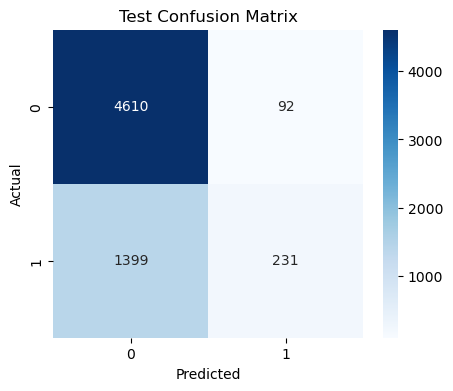

In [15]:
# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

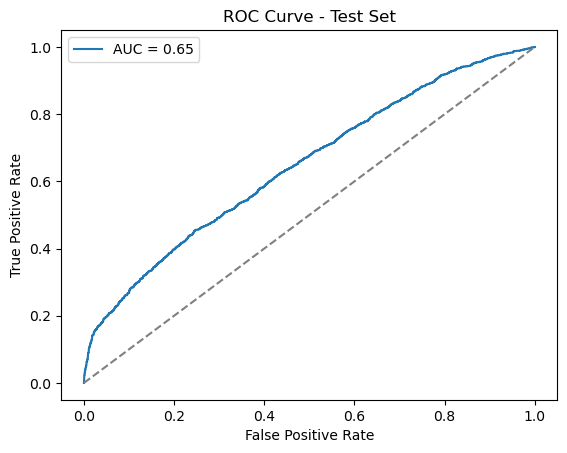

In [16]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_test_proba):.2f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.title("ROC Curve - Test Set")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

Feature Importance

C:\Users\User\AppData\Local\Temp\ipykernel_10228\1964385028.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette="mako")


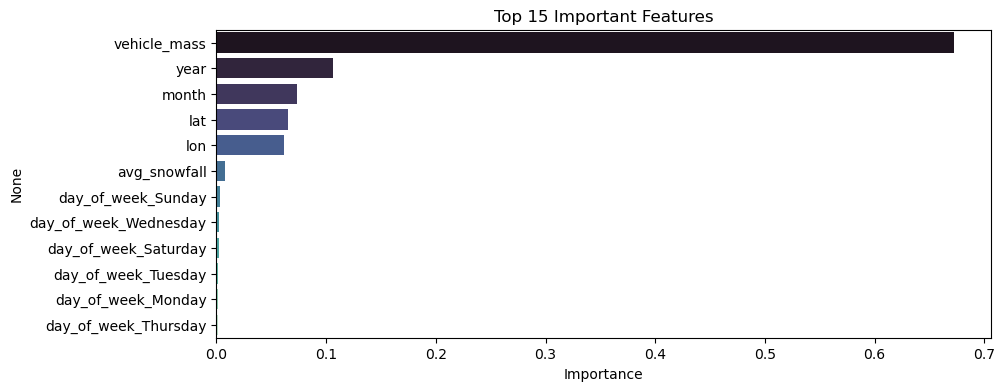

In [17]:
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,4))
sns.barplot(x=top_features.values, y=top_features.index, palette="mako")
plt.title("Top 15 Important Features")
plt.xlabel("Importance")
plt.show()

|--- vehicle_mass <= 378.00
|   |--- lon <= 22.38
|   |   |--- lat <= 60.50
|   |   |   |--- day_of_week_Thursday <= 0.50
|   |   |   |   |--- lon <= 21.92
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- lon >  21.92
|   |   |   |   |   |--- class: 0.0
|   |   |   |--- day_of_week_Thursday >  0.50
|   |   |   |   |--- class: 0.0
|   |   |--- lat >  60.50
|   |   |   |--- vehicle_mass <= 349.00
|   |   |   |   |--- day_of_week_Thursday <= 0.50
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- day_of_week_Thursday >  0.50
|   |   |   |   |   |--- class: 0.0
|   |   |   |--- vehicle_mass >  349.00
|   |   |   |   |--- lon <= 22.00
|   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- lon >  22.00
|   |   |   |   |   |--- class: 1.0
|   |--- lon >  22.38
|   |   |--- day_of_week_Saturday <= 0.50
|   |   |   |--- lat <= 60.99
|   |   |   |   |--- year <= 2016.50
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- year >  2016.50
|   |   |   |   |   |--- class: 1.0
| 

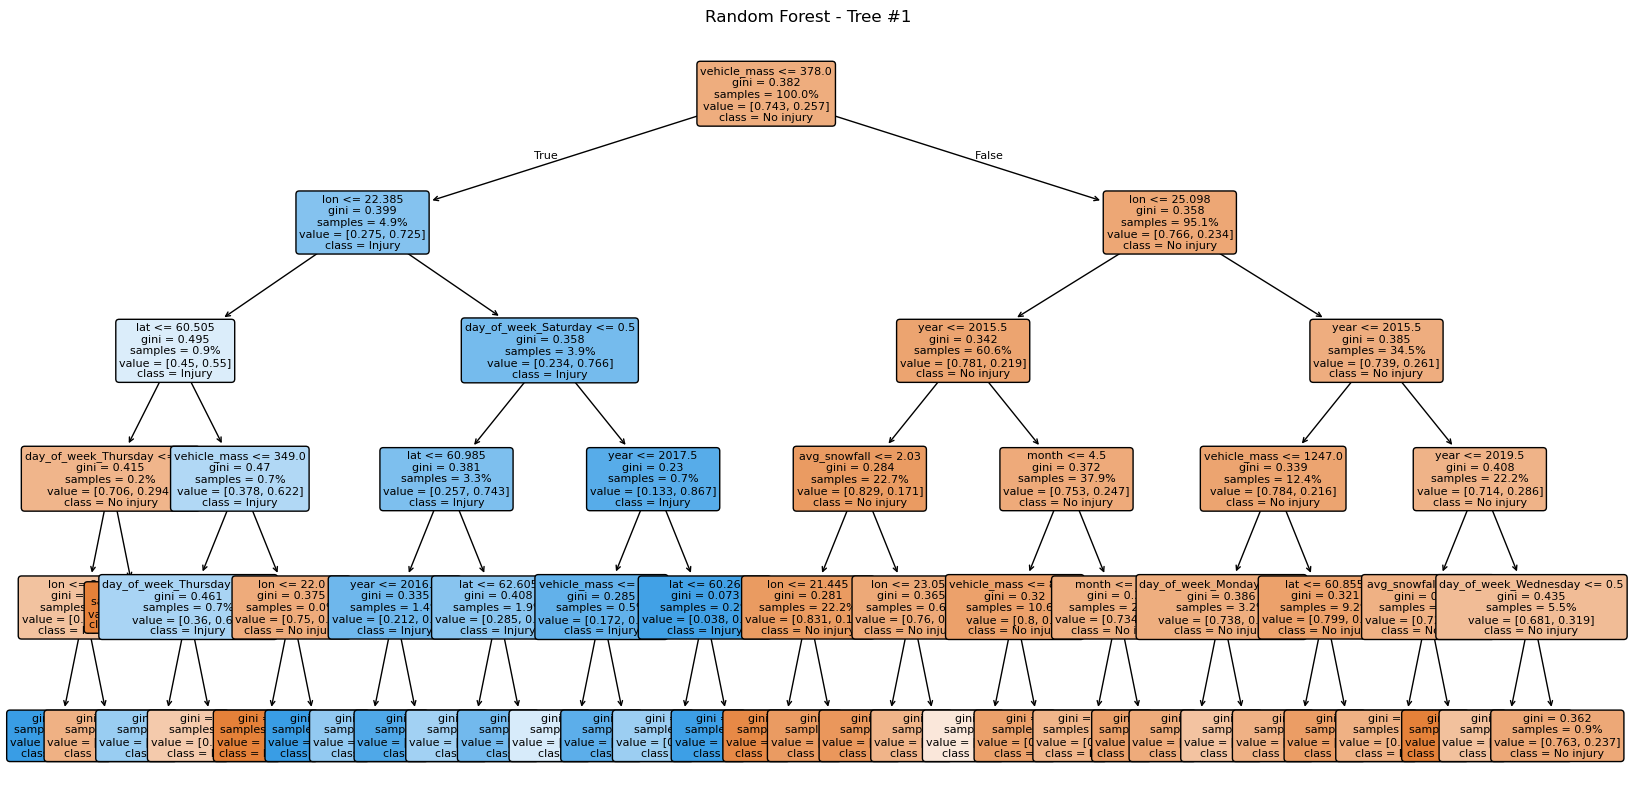

In [19]:
# Print and plot a single decision tree from the trained RandomForest (best_rf)
# If you want a different tree, change `tree_index`.
from sklearn import tree
from sklearn.tree import export_text, plot_tree
import matplotlib.pyplot as plt

# Choose which estimator (tree) in the forest to visualise
tree_index = 1  # valid range: 0 .. len(best_rf.estimators_) - 1
est = best_rf.estimators_[tree_index]

# Print a textual representation of the tree
try:
    feature_names = list(X.columns)
except Exception:
    feature_names = None

print(
    export_text(est, feature_names=feature_names)
)

# Plot the tree (may be large)
plt.figure(figsize=(20, 10))
plot_tree(est, feature_names=feature_names, class_names=['No injury','Injury'], filled=True, rounded=True, proportion=True, fontsize=8)
plt.title(f'Random Forest - Tree #{tree_index}')
plt.show()

# Notes:
# - To export to Graphviz DOT: use export_graphviz(est, out_file='tree.dot', feature_names=feature_names, class_names=['No injury','Injury'], rounded=True, filled=True)
# - If running in a headless environment, reduce figure size or save to file with plt.savefig('tree.png', dpi=200)